# Лабораторная работа 1

Тема: **Искусственный нейрон и функции активации**  
Цель: познакомиться с моделью искусственного нейрона, реализовать основные функции активации и визуализировать решающую границу на плоскости.

> ВАЖНО: все формулировки заданий в этом ноутбуке достаточно общие и абстрактные.  
> Не копируйте их целиком в сторонние сервисы автоматической генерации решений.  
> Оценка будет ставиться только за ваш собственный код, графики и пояснения.

## 1. Вводные теоретические вопросы

Ответьте **своими словами** на вопросы ниже. Строго запрещается вставлять сюда автоматически сгенерированный текст; преподаватель проверяет стиль и логику изложения.

1. Что такое искусственный нейрон? Какие величины входят в его модель и что они означают?
2. Зачем в нейронной сети нужна функция активации? Что будет, если использовать только линейные функции?
3. Назовите не менее трех различных функций активации и кратко опишите их поведение (какие значения принимают, где насыщаются, где линейны).
4. Как можно интерпретировать выход одного нейрона в задачах бинарной классификации?

Напишите ответы в следующей ячейке (в свободной форме, 5–10 предложений суммарно).

### Ответы на теоретические вопросы (заполните самостоятельно)

_Напишите здесь текст своими словами.  
Не копируйте формулировки из конспекта или интернета дословно — важно, чтобы вы сами понимали материал._

In [ ]:
# Здесь должен быть ваш текстовый ответ, оформленный как многострочная строка, 
# комментарии или вывод через print.

theory_answer = """
1. Искусственый нейрон - это модель естественного нейрона (элемент нервной системы у человека), который используется 
в области машинного обучения для построения искусственной нейронной сети. 
В искусственный нейрон входят такие величины как:
    1. Входы (аналог синапса) - передаёт информацию на следующие уровни
    2. Весовые коэффиценты - определяет насколько нейрон чувствителен к изменению конкретного значения.
    3. Функции активации - преобразует входные сигналы в выходной сигнал.
    4. Выход (аксон) - значение, которое формируется в результате обработки входных сигналов.

2. Функция активации в нейронной сети нужна для того чтобы модель могла изучать сложные шаблоны данных 
или другими словами избавиться от линейности сети.
Если использовать только линейный функции, сеть будет ограничена по разным причинам:
    1. Если все слои будут использовать линейную функцию активации  => выходное значение каждого слоя будет линейно =>
    последняя функция активации на последнем слое будет зависеть только от входных значений на первом слое.
    2. Существует некоторые алгоритмы обучения, которые не подходят для линейных функций, например градиентый спуск. Так как
    в этом методе используется взятие производной, а производная от линейной функции это const => не зависит от входных значений.

3. Функции активации:
    1. Sigmoid - преобразует входные данные в вероятностное значение от 0 до 1. 
    Насыщение:
    при x -> inf - стремится к 1,
    при x -> -inf - стремится к 0,
    Нелинейна на всем диапозоне. S-образная форма.

    2. Tahn - отображает входные данные в диапазоне от –1 до +1.
    Насыщение:
    при x -> inf - стремится к +1,
    при x -> -inf - стремится к -1,
    Нелинейна.

    3. ReLu - для положительных значений возвращает исходное значение, для отрицательных — 0.
    Нет насыщения для положительных входов (x > 0):
    Линейна для всех положительных значений x.

    4. Выход одного нейрона в задачах бинарной классификации можно интерпретировать как вероятность принадлежности
    к определённому классу.

"""

print(theory_answer)

## 2. Импорт библиотек и базовые настройки

Выполните импорт необходимых библиотек и задайте настройки визуализации.  
Используйте только те библиотеки, которые разрешены преподавателем.

**Задание 2.1.**
- Импортируйте `numpy` и `matplotlib.pyplot`.  
- Установите фиксированное зерно генератора случайных чисел для воспроизводимости.  
- Включите любой стиль оформления графиков (по вашему выбору).

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Задайте зерно (seed) случайного генератора
np.random.seed(0)

# Выберите стиль оформления графиков (можно изменить, если хотите)
plt.style.use("seaborn-v0_8")  # при необходимости замените на другой стиль

print("Библиотеки успешно импортированы. Seed установлен.")

Библиотеки успешно импортированы. Seed установлен.


## 3. Реализация функций активации

В этом разделе вы реализуете несколько функций активации и построите их графики.

**Задание 3.1.** Реализуйте следующие функции активации:
- Линейная функция  
- Сигмоида  
- Гиперболический тангенс  
- ReLU (Rectified Linear Unit)

Каждая функция должна корректно работать как с отдельным числом, так и с массивом NumPy.

**Задание 3.2.** Постройте на одном графике зависимости этих функций от аргумента `z` на отрезке от −5 до 5.  
Сделайте осмысленные подписи осей и легенду на русском языке.

_Подсказка: если вы не уверены в формулах, сначала запишите их в тетрадке или на листке и только потом реализуйте в коде._

In [10]:
# Реализуйте функции активации ЗДЕСЬ.
# Не оставляйте заглушки вида pass и None — каждая функция должна возвращать корректный результат.

def activation_linear(z):
    """Линейная функция активации.
       Формула f(z) = z;
       (-inf; inf)
       
    """
    return z

def activation_sigmoid(z):
    """Сигмоида.
    1 / (1 + e^(-z))
    (0; 1)
    """
    # TODO: реализуйте сигмоидную функцию
    return 1 / (1 + np.exp(-z))

def activation_tanh(z):
    """Гиперболический тангенс.
    (e^z - e^(-z)) / (e^z + e^(-z))
    (-1; 1)
    """
    # TODO: реализуйте tanh через np.tanh
    return np.tanh(z)

def activation_relu(z):
    """Функция ReLU.
    max(0, z)
    [0; +inf]
    """
    z = np.array(z)
    return np.maximum(0, z)

# Простейшая самопроверка на одном числе
test_value = -1.5
print("Проверка на одном значении:")
print("linear:", activation_linear(test_value))
print("sigmoid:", activation_sigmoid(test_value))
print("tanh:", activation_tanh(test_value))
print("ReLU:", activation_relu(test_value))

# Простейшая самопроверка на массиве
test_array = np.array([1.0, 2.0])
print("Проверка на массиве:")
print("linear:", activation_linear(test_array))
print("sigmoid:", activation_sigmoid(test_array))
print("tanh:", activation_tanh(test_array))
print("ReLU:", activation_relu(test_array))

Проверка на одном значении:
linear: -1.5
sigmoid: 0.18242552380635635
tanh: -0.9051482536448665
ReLU: 0.0
Проверка на массиве:
linear: [1. 2.]
sigmoid: [0.73105858 0.88079708]
tanh: [0.76159416 0.96402758]
ReLU: [1. 2.]


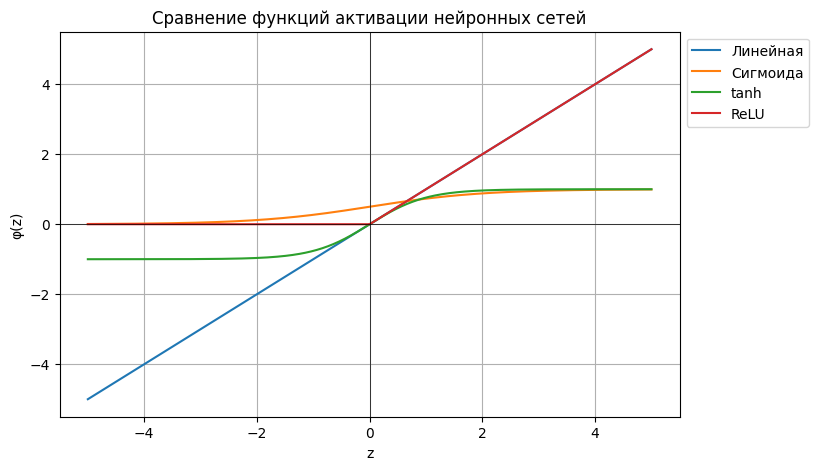

In [37]:
# ПОСТРОЙКА ГРАФИКОВ ФУНКЦИЙ АКТИВАЦИИ
import numpy as np
import matplotlib.pyplot as plt



z = np.linspace(-5, 5, 400)

plt.figure(figsize=(8, 5))
plt.plot(z, activation_linear(z), label="Линейная")
plt.plot(z, activation_sigmoid(z), label="Сигмоида")
plt.plot(z, activation_tanh(z), label="tanh")
plt.plot(z, activation_relu(z), label="ReLU")


plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("z")
plt.ylabel("φ(z)")
plt.title("Сравнение функций активации нейронных сетей")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

## 4. Реализация одиночного нейрона

Теперь реализуем модель одиночного нейрона, который:
- получает на вход вектор признаков `x`,
- умножает его на вектор весов `w`,
- добавляет смещение `b`,
- применяет одну из реализованных выше функций активации.

**Задание 4.1.** Реализуйте функцию `single_neuron(x, w, b, activation_name)`, которая:
- поддерживает вход `x` как одномерный массив (один объект) и как двумерный массив (несколько объектов),
- использует одну из функций активации по имени (`"linear"`, `"sigmoid"`, `"tanh"`, `"relu"`).

Не копируйте готовые куски кода из интернета: здесь важно, чтобы вы сами продумали форму массивов и математику.


In [40]:
def single_neuron(x, w, b, activation_name="relu"):
    """Вычисляет выход одиночного нейрона для входа x.

    x: np.ndarray формы (n_features,) или (n_samples, n_features)
    w: np.ndarray формы (n_features,)
    b: число (смещение)
    activation_name: строка с названием функции активации
    """
    # Приводим x к двумерному виду для удобства вычислений
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # TODO: реализуйте линейную комбинацию для z используя @ (матричное умножение - семантика np.matmul)
    z = x @ w + b

    if activation_name == "linear":
        return activation_linear(z)
    elif activation_name == "sigmoid":
        return activation_sigmoid(z)
    elif activation_name == "tanh":
        return activation_tanh(z)
    elif activation_name == "relu":
        return activation_relu(z)
    else:
        raise ValueError("Неизвестная функция активации: " + str(activation_name))

# Краткая проверка на одном примере
# TODO: задайте одномерные массивы для входа и весов, и число для смещения
x_example = np.array([1.0, 2.0, 3.0]) 
w_example = np.array([0.1, 0.2, 0.3]) 
b_example = 0.1  

for name in ["linear", "sigmoid", "tanh", "relu"]:
    y_example = single_neuron(x_example, w_example, b_example, activation_name=name)
    print(f"Активация {name}, выход: {y_example}")

x_batch = np.array([[1.0, 2.0, 3.0],
                     [2.0, -1.0, 0.5]])  
y_batch = single_neuron(x_batch, w_example, b_example, "sigmoid")
print("Выход для группы данных:", y_batch)


Активация linear, выход: [1.5]
Активация sigmoid, выход: [0.81757448]
Активация tanh, выход: [0.90514825]
Активация relu, выход: [1.5]
Выход для группы данных: [0.81757448 0.5621765 ]


## 5. Визуализация решающей границы нейрона

Рассматриваем двумерный вход `x = (x1, x2)`. Для нейрона вида
\( $y = \sigma(w_1 x_1 + w_2 x_2 + b)$ \)  
линия уровня, соответствующая `y ≈ 0.5`, задает **решающую границу**.

**Задание 5.1.**
- Выберите произвольные значения весов `w1`, `w2` и смещения `b` (не все нули).  
- Постройте на плоскости поле значений выхода нейрона (например, с сигмоидой).  
- Нарисуйте линию решающей границы (уровень ~0.5 для сигмоиды).

**Задание 5.2.**
- С помощью изменения `w` и `b` проанализируйте, как меняется положение и наклон границы.  
- Сформулируйте **2–3 предложения** с описанием наблюдений в отдельной текстовой ячейке.


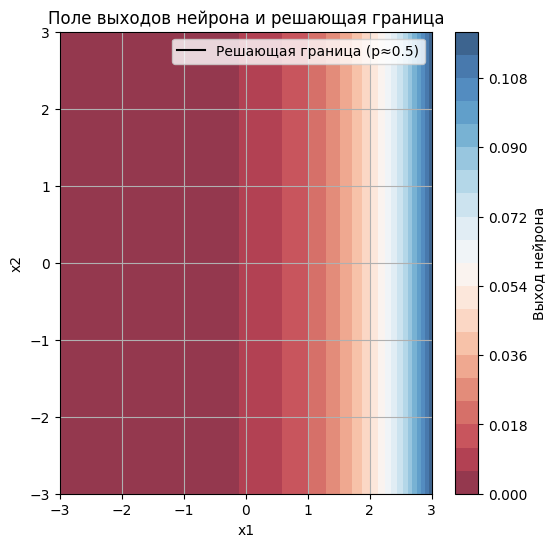

In [55]:
# ВЫБОР ПАРАМЕТРОВ НЕЙРОНА (измени́те их и посмотрите на результат)
w_demo = np.array([1.0, 0.0])   # попробуйте разные значения
b_demo = -5.0                    # попробуйте сдвинуть границу

# Сетка точек на плоскости
x1_min, x1_max = -3.0, 3.0
x2_min, x2_max = -3.0, 3.0

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Выход нейрона с сигмоидальной активацией
probs = single_neuron(grid, w_demo, b_demo, activation_name="sigmoid")
probs = probs.reshape(xx1.shape)

plt.figure(figsize=(6, 6))
cs = plt.contourf(xx1, xx2, probs, levels=20, cmap="RdBu", alpha=0.8)
plt.colorbar(cs, label="Выход нейрона")

# Линия решающей границы (уровень ~0.5)
contours = plt.contour(xx1, xx2, probs, levels=[0.5], colors="black")
plt.plot([], [], color="black", label="Решающая граница (p≈0.5)")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Поле выходов нейрона и решающая граница")
plt.legend()
plt.grid(True)
plt.show()

### Комментарии по влиянию параметров на решающую границу

_Опишите своими словами, как изменение вектора весов и смещения влияет на положение и наклон границы.  
Ответ должен опираться на ваши собственные эксперименты с кодом выше (изменение `w_demo` и `b_demo`)._

In [ ]:
boundary_comment = """ЗДЕСЬ КРАТКО ОПИШИТЕ НАБЛЮДЕНИЯ.
1) Увеличение w1 и w2 - не меняет уровень наклона решающей границы, но делает 
переход между классами менее плавными. Область уверенной классификации расширяется, а
зона неопределённости сужается.
2) Изменение b сдвигает решающую границу параллельно самой себе.Увеличение b 
перемещает границу в направлении, противоположном вектору весов, 
а уменьшение b — в направлении этого вектора.
3) отношение w1 к w2 определяет наклон решающей границы. при w1 = 0, 
граница становится вертикальной, при w2 = 0 - горизонтальной.
 """

print(boundary_comment)

## 6. Ручной подбор нейрона для разделения двух классов

Сгенерируем на плоскости два кластера точек (два класса) и попробуем подобрать параметры нейрона так, чтобы он их разделял.

**Задание 6.1.**
- Сгенерируйте два набора точек (по 50–200 в каждом) из разных двумерных нормальных распределений (центры и ковариации выберите сами).  
- Объедините их в одну выборку `X` и массив меток `y` (0 и 1).

**Задание 6.2.**
- Подберите вручную (методом проб и ошибок) веса `w_try` и смещение `b_try` для нейрона с сигмоидой.  
- Визуализируйте точки двух классов и решающую границу.  
- Оцените долю правильно классифицированных точек.

Рекомендуется **несколько раз менять** параметры и смотреть, как меняется качество разделения. Это важная часть работы и проверка интуиции.

In [56]:
# ГЕНЕРАЦИЯ ДВУХ КЛАССОВ

n_samples = 100  # при желании можно изменить

# TODO: Задайте центры и ковариационные матрицы для двух классов
mean_class0 = np.array([-1, -1]) #(смещён влево-вниз)
mean_class1 = np.array([1, 1]) #(смещён вправо-вверх)

cov_class0 = np.array([[0.5, 0],   # ковариационная матрица для класса 0
                       [0, 0.5]])
cov_class1 = np.array([[0.5, 0],   # ковариационная матрица для класса 1
                       [0, 0.5]])

class0 = np.random.multivariate_normal(mean_class0, cov_class0, size=n_samples)
class1 = np.random.multivariate_normal(mean_class1, cov_class1, size=n_samples)

# Объедините массивы class0 и class1 в одну матрицу X формы (n_samples, 2)
# Подсказка: используйте функции объединения из numpy (например, vstack или concatenate)
X = np.vstack([class0, class1])

# TODO: Создайте вектор ответов y формы (n_samples,).
# Первые n_samples элементов должны быть 0, а вторые n_samples элементов — 1.
y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])  

print("Форма X:", X.shape)
print("Форма y:", y.shape)

Форма X: (200, 2)
Форма y: (200,)


Доля правильных классификаций при w=[1. 1.], b=-2.0: 0.730


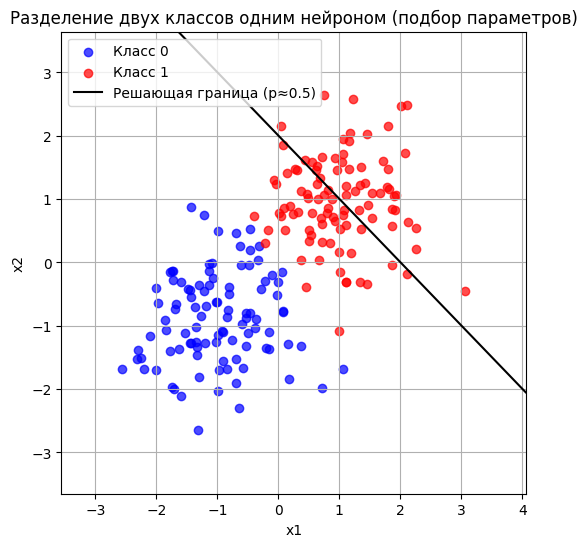

In [73]:
# РУЧНОЙ ПОДБОР ПАРАМЕТРОВ НЕЙРОНА

# Попробуйте изменить эти значения и перезапустить ячейку
w_try = np.array([1.0, 1.0])
b_try = -2.0

# Выход нейрона (вероятности для класса 1)
probs_data = single_neuron(X, w_try, b_try, activation_name="sigmoid").ravel()
# TODO: Переведите вероятности (probs_data) в бинарные предсказания классов (0 или 1).
# Подсказка: используйте порог 0.5. Все, что больше или равно — класс 1, иначе — 0. Не забудьте привести к int
y_pred = (probs_data >= 0.5).astype(int)
# TODO: Посчитайте долю правильных ответов (accuracy).
# Сравните предсказанные метки y_pred с истинными метками y.
accuracy = np.mean(y_pred == y)

print(f"Доля правильных классификаций при w={w_try}, b={b_try}: {accuracy:.3f}")

# Визуализация
plt.figure(figsize=(6, 6))
plt.scatter(class0[:, 0], class0[:, 1], c="blue", label="Класс 0", alpha=0.7)
plt.scatter(class1[:, 0], class1[:, 1], c="red", label="Класс 1", alpha=0.7)

# Решающее множество на сетке для визуализации границы
x1_min_data, x1_max_data = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min_data, x2_max_data = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1_d, xx2_d = np.meshgrid(
    np.linspace(x1_min_data, x1_max_data, 200),
    np.linspace(x2_min_data, x2_max_data, 200)
)

grid_d = np.c_[xx1_d.ravel(), xx2_d.ravel()]
probs_grid_d = single_neuron(grid_d, w_try, b_try, activation_name="sigmoid").reshape(xx1_d.shape)

contours_d = plt.contour(xx1_d, xx2_d, probs_grid_d, levels=[0.5], colors="black")
plt.plot([], [], color="black", label="Решающая граница (p≈0.5)")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Разделение двух классов одним нейроном (подбор параметров)")
plt.legend()
plt.grid(True)
plt.show()

### Краткие выводы по разделению классов

_Сформулируйте 3–5 предложений о том, удалось ли разделить классы одним нейроном,  
насколько хорошо это получилось и от чего зависит качество разделения._

In [ ]:
separation_comment = """ЗДЕСЬ ОПИШИТЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ.
1) w = [1.0, 1.0], b = 0.0 -> accuracy = 0.990
Граница проходит примерно под 45°, хорошо разделяет классы — они изначально расположены в разных квадрантах 
(класс 0 около (-1, -1), класс 1 около (1, 1)).

2) w = [2.0, 1.0], b = -0.5 -> accuracy = 0.985
Наклон границы изменился (стала более пологой), качество немного снизилось:
часть точек оказалась по «неправильную» сторону.

3) w = [1.0, 1.0], b = -2.0 -> accuracy = 0.730
Граница ушла слишком далеко в сторону класса 1 — модель «угадала» лишь около половины случаев (близко к случайному угадыванию).

Таким образом, один нейрон эффективно разделяет классы, если данные линейно разделимы, 
а параметры подобраны корректно. 
При значительном сдвиге границы или неудачном наклоне качество классификации заметно падает.
"""

print(separation_comment)

## 7. Итоговые выводы по лабораторной работе

В завершение сформулируйте **собственный** короткий вывод (5–8 предложений) по всей работе:
- какую модель вы реализовали,  
- что нового узнали про функции активации и решающие границы,  
- что показали эксперименты с двумя классами данных.

Этот раздел очень важен для оценки: по нему видно, что вы действительно продумали проделанные шаги.

In [74]:
final_conclusion = """
В ходе лабораторной работы я реализовал простейшую модель искусственного нейрона для задачи бинарной классификации. 
На практике убедился, как работает сигмоидальная функция активации: 
она преобразует линейную комбинацию входных признаков в вероятность принадлежности к классу 1,
позволяя интерпретировать выход нейрона в диапазоне от 0 до 1.
Эксперименты с решающей границей наглядно показали её геометрический смысл: 
это прямая линия (в двумерном случае), перпендикулярная вектору весов. 
Я увидел, что параметры нейрона напрямую управляют положением и наклоном границы: 
веса задают направление и крутизну разделения,
а смещение сдвигает границу в пространстве без изменения наклона.

Опыты с двумя классами данных подтвердили: один нейрон способен достичь высокой точности классификации (до 99 %) 
при условии линейной разделимости классов. 
Когда кластеры хорошо отделены друг от друга (как в нашем случае — центры в разных квадрантах), 
даже ручной подбор параметров даёт отличный результат. 
Однако при сильном сдвиге границы или неудачном наклоне точность резко падает, 
что демонстрирует ограничения однонейронной модели.

Таким образом, работа позволила на практике связать теорию нейронных сетей с визуальной интерпретацией: 
я увидел, как математические параметры влияют на геометрию разделения и качество классификации.
"""


print(final_conclusion)



В ходе лабораторной работы я реализовал простейшую модель искусственного нейрона для задачи бинарной классификации. 
На практике убедился, как работает сигмоидальная функция активации: 
она преобразует линейную комбинацию входных признаков в вероятность принадлежности к классу 1,
позволяя интерпретировать выход нейрона в диапазоне от 0 до 1.
Эксперименты с решающей границей наглядно показали её геометрический смысл: 
это прямая линия (в двумерном случае), перпендикулярная вектору весов. 
Я увидел, что параметры нейрона напрямую управляют положением и наклоном границы: 
веса задают направление и крутизну разделения,
а смещение сдвигает границу в пространстве без изменения наклона.

Опыты с двумя классами данных подтвердили: один нейрон способен достичь высокой точности классификации (до 99 %) 
при условии линейной разделимости классов. 
Когда кластеры хорошо отделены друг от друга (как в нашем случае — центры в разных квадрантах), 
даже ручной подбор параметров даёт отличный результат.